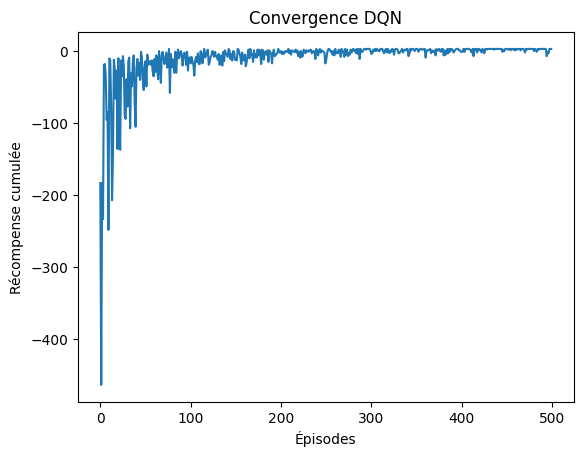

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import torch
import torch.nn as nn
import torch.optim as optim
from environment.warehouse_env import WarehouseEnv

# Hyperparamètres
episodes = 500
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
lr = 0.001
batch_size = 64
memory_size = 10000

# Réseau de neurones
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

# Replay Buffer
class ReplayBuffer:
    def __init__(self, max_size):
        self.buffer = deque(maxlen=max_size)

    def add(self, experience):
        self.buffer.append(experience)

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

    def size(self):
        return len(self.buffer)

# Initialisation
env = WarehouseEnv(grid_size=(5, 5))
state_dim = 2   # (x, y)
action_dim = len(env.action_space)

policy_net = DQN(state_dim, action_dim)
target_net = DQN(state_dim, action_dim)
target_net.load_state_dict(policy_net.state_dict())
optimizer = optim.Adam(policy_net.parameters(), lr=lr)
memory = ReplayBuffer(memory_size)

def choose_action(state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.choice(env.action_space)
    state_tensor = torch.FloatTensor(state).unsqueeze(0)
    q_values = policy_net(state_tensor)
    return torch.argmax(q_values).item()

def train_step():
    if memory.size() < batch_size:
        return
    batch = memory.sample(batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)

    states = torch.FloatTensor(states)
    actions = torch.LongTensor(actions).unsqueeze(1)
    rewards = torch.FloatTensor(rewards)
    next_states = torch.FloatTensor(next_states)
    dones = torch.FloatTensor(dones)

    q_values = policy_net(states).gather(1, actions).squeeze()
    next_q_values = target_net(next_states).max(1)[0]
    target = rewards + gamma * next_q_values * (1 - dones)

    loss = nn.MSELoss()(q_values, target.detach())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Entraînement
rewards_per_episode = []

for ep in range(episodes):
    state = env.reset()
    total_reward = 0

    while True:
        action = choose_action(state, epsilon)
        new_state, reward, done = env.step(action)
        memory.add((state, action, reward, new_state, done))

        train_step()

        state = new_state
        total_reward += reward

        if done:
            break

    rewards_per_episode.append(total_reward)

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    target_net.load_state_dict(policy_net.state_dict())

# Visualisation
plt.plot(rewards_per_episode)
plt.xlabel("Épisodes")
plt.ylabel("Récompense cumulée")
plt.title("Convergence DQN")
plt.show()

In [2]:
import imageio
import os
import torch

# Créer le dossier demo si nécessaire
os.makedirs("demo", exist_ok=True)

frames = []
state = env.reset()
done = False

while not done:
    # Politique exploitante : choisir l'action avec le plus grand Q
    state_tensor = torch.FloatTensor(state).unsqueeze(0)
    q_values = policy_net(state_tensor)
    action = torch.argmax(q_values).item()

    new_state, reward, done = env.step(action)

    frame = env.render()   # retourne une image numpy
    frames.append(frame)

    state = new_state

# Sauvegarde en vidéo avec FFMPEG
imageio.mimsave("demo/demo_dqn.mp4", frames, fps=2, codec="libx264")
print("Vidéo sauvegardée dans demo/demo_dqn.mp4")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (500, 500) to (512, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Vidéo sauvegardée dans demo/demo_dqn.mp4
